In [ ]:
1.TIME-SERIES ANALYSIS:-

In [ ]:
1.1 Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ramya\Downloads\health_time_series_dataset.csv")
df

,Date,Systolic_BP,Diastolic_BP,Blood_Sugar
0,2023-01-01,120,80,180
1,2023-01-02,118,78,175
2,2023-01-03,122,82,182
3,2023-01-04,125,85,190
4,2023-01-05,123,83,185
5,2023-01-06,121,81,178
6,2023-01-07,119,79,172
7,2023-01-08,117,77,170
8,2023-01-09,116,76,168
9,2023-01-10,118,78,171


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

In [4]:
df.head()

,Systolic_BP,Diastolic_BP,Blood_Sugar
Date,,,
2023-01-01,120,80,180
2023-01-02,118,78,175
2023-01-03,122,82,182
2023-01-04,125,85,190
2023-01-05,123,83,185


In [ ]:
1.2Visualize the time series (Trend)

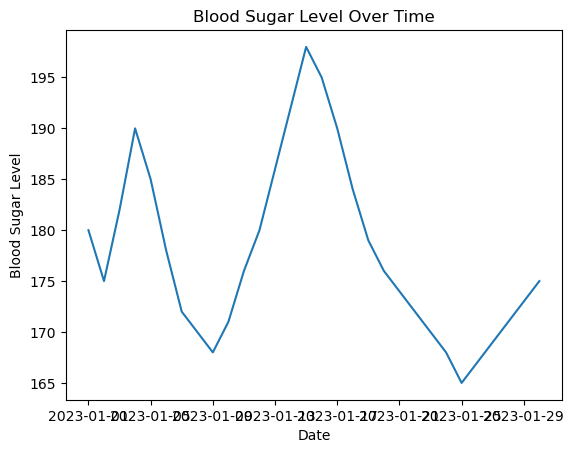

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df.index, df["Blood_Sugar"])
plt.xlabel("Date")
plt.ylabel("Blood Sugar Level")
plt.title("Blood Sugar Level Over Time")
plt.show()

In [ ]:
1.3 Rolling Mean (Moving Average)

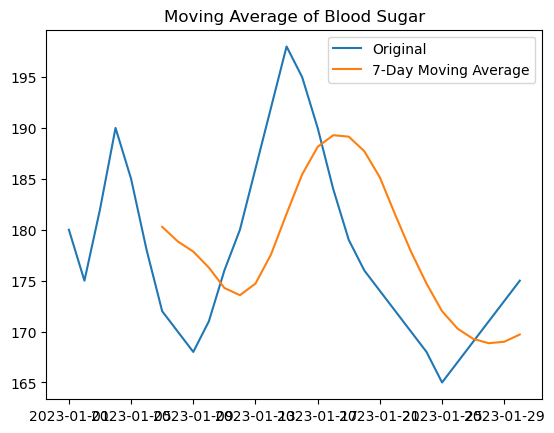

In [6]:
df["Rolling_Mean_7"] = df["Blood_Sugar"].rolling(window=7).mean()

plt.figure()
plt.plot(df["Blood_Sugar"], label="Original")
plt.plot(df["Rolling_Mean_7"], label="7-Day Moving Average")
plt.legend()
plt.title("Moving Average of Blood Sugar")
plt.show()

In [ ]:
1.4 Check Stationarity (ADF Test):
ARIMA requires stationary data.

In [7]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Blood_Sugar"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.7442540852396577
p-value: 0.0666884106672105


In [ ]:
1.5 ARIMA Model:
We’ll use ARIMA(1,1,1) (standard for demos).

In [8]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df["Blood_Sugar"], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            Blood_Sugar   No. Observations:                   30
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -76.874
Date:                Thu, 01 Jan 2026   AIC                            159.748
Time:                        13:41:27   BIC                            163.849
Sample:                    01-01-2023   HQIC                           161.032
                         - 01-30-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2640      0.318      0.830      0.407      -0.360       0.888
ma.L1          0.5552      0.250      2.222      0.026       0.066       1.045
sigma2        11.4624      3.860      2.969      0.0

C:\Users\ramya\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\ramya\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\ramya\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
1.6 Forecast Future Values
Forecast next 7 days.

In [9]:
forecast = model_fit.forecast(steps=7)
print(forecast)

2023-01-31    176.206771
2023-02-01    176.525350
2023-02-02    176.609453
2023-02-03    176.631656
2023-02-04    176.637517
2023-02-05    176.639064
2023-02-06    176.639473
Freq: D, Name: predicted_mean, dtype: float64


In [ ]:
1.7 Plot Forecast

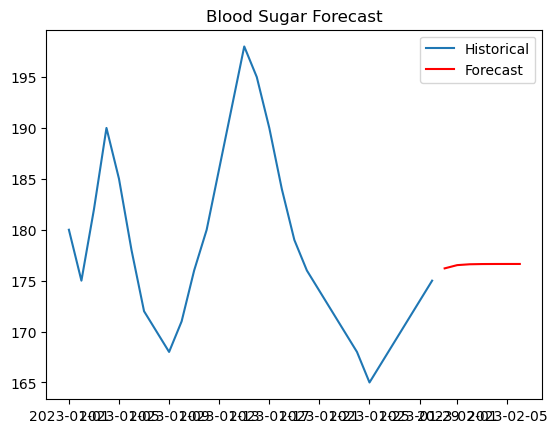

In [10]:
plt.figure()
plt.plot(df.index, df["Blood_Sugar"], label="Historical")
plt.plot(forecast.index, forecast, label="Forecast", color="red")
plt.legend()
plt.title("Blood Sugar Forecast")
plt.show()

In [ ]:
REPORT:
1) Problem Type:
Time Series Analysis

2)Dataset:
Healthcare time series dataset with daily blood sugar levels

3)Techniques Used:
Trend Analysis
Moving Average
Stationarity Test (ADF)
ARIMA Forecasting

4)Conclusion:
The ARIMA model successfully captured the temporal pattern and was used to forecast future blood sugar levels.